<a href="https://colab.research.google.com/github/SinnottKayleigh/B2B-Sales-Algos/blob/main/Bayesian_Neural_Networks_(BNNs).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Bayesian Neural Networks; **handles uncertainty and makes more informed decisions based on probabilistic models - mainly concerned with the inference from your data.

- Specify priors to inform and constrain our models and get uncertainty estimaiton in form of a posterior distribution.




**Lead Scoring and Prediction:**

- Predict the liklihood of a lead converting into a customer by considering the uncertainty in the data and model parameters.

- BNN provides a distribution of possible outcomes, useful for understanding the confidence behind predictions, as opposed to vanilla ML models.

**Customer Segmentation:**

- considers the uncertainty in identifying which customers belong to which segments. Uses features like company attributes, past purchases, engagement levels and behaviour.

**Lead Generation via Predictive Insights:**

- Estimates the probability of a lead being successful based on various features, such as interactions, past data, behaviour patterns, etc.
- Uses the bayesian model to update the probability of a lead being successful as new data comes in, adapting to new trends and patterns as lead gen strategy evolves.
- BNN Provides a confidence score for each lead.

**Churn Prediction:**

- Provide probabilistic estimates of churn, along with uncertainty to help the sales team take preventative actions for deals slipping.
- customer interaction history; uses features such as recent product usage, engagement, customer satisfaction, support interactions, etc.

**Personalised recommendation for leads:**
- takes into account the leads behaviour and interactions, while additionally the uncertainty.




In [6]:
pip install torch numpy pandas scikit-learn Faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 858.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from faker import Faker
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

class BayesianNeuralNetwork(nn.Module):
    def __init__(self, input_dim, hidden_layers, output_dim):
        super(BayesianNeuralNetwork, self).__init__()

        # Create layers dynamically
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))
            prev_dim = hidden_dim

        # Final output layer
        layers.append(nn.Linear(prev_dim, output_dim))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

class B2BSalespredictor:
    def __init__(self, hidden_layers=[50, 30]):
        self.scaler = StandardScaler()
        self.label_encoders = {}
        self.hidden_layers = hidden_layers

    def generate_synthetic_data(self, num_samples=1000):
        fake = Faker()

        data = {
            'company_age': np.random.randint(1, 20, num_samples),
            'annual_revenue': np.random.uniform(100000, 10000000, num_samples),
            'employee_count': np.random.randint(10, 500, num_samples),
            'previous_purchases': np.random.randint(0, 10, num_samples),
            'customer_support_interactions': np.random.randint(0, 50, num_samples),
            'product_complexity': np.random.uniform(1, 10, num_samples),
            'contract_duration': np.random.randint(1, 5, num_samples),
            'industry_type': np.random.choice(['Tech', 'Finance', 'Retail', 'Manufacturing'], num_samples),
            'geographic_region': np.random.choice(['North', 'South', 'East', 'West'], num_samples),
            'technology_adoption_rate': np.random.uniform(0, 1, num_samples)
        }

        df = pd.DataFrame(data)

        # Synthetic target variables
        df['lead_score'] = np.random.uniform(0, 100, num_samples)
        df['customer_segment'] = np.random.choice(['A', 'B', 'C', 'D'], num_samples)
        df['churn_probability'] = np.random.uniform(0, 1, num_samples)

        return df

    def prepare_data(self, df):
        # One-hot encode categorical variables
        df_encoded = pd.get_dummies(df, columns=['industry_type', 'geographic_region'])

        # Separate features and targets
        X = df_encoded.drop(['lead_score', 'customer_segment', 'churn_probability'], axis=1)

        # Encode customer segment
        le_segment = LabelEncoder()
        y_customer_segment = le_segment.fit_transform(df_encoded['customer_segment'])
        self.label_encoders['customer_segment'] = le_segment

        # Prepare target variables
        y_lead_score = df_encoded['lead_score'].values
        y_churn = df_encoded['churn_probability'].values

        # Scale features
        X_scaled = self.scaler.fit_transform(X)

        return (torch.FloatTensor(X_scaled),
                torch.FloatTensor(y_lead_score).unsqueeze(1),
                torch.LongTensor(y_customer_segment),
                torch.FloatTensor(y_churn).unsqueeze(1))

    def create_models(self, X):
        input_dim = X.shape[1]

        # Create models with correct input dimensions
        self.lead_scoring_model = BayesianNeuralNetwork(
            input_dim,
            self.hidden_layers,
            output_dim=1
        )

        self.customer_segmentation_model = BayesianNeuralNetwork(
            input_dim,
            self.hidden_layers,
            output_dim=4  # Assuming 4 customer segments
        )

        self.churn_prediction_model = BayesianNeuralNetwork(
            input_dim,
            self.hidden_layers,
            output_dim=1
        )

    def train_models(self, X, y_lead_score, y_customer_segment, y_churn, epochs=100):
        # Create models with correct input dimensions
        self.create_models(X)

        # Split data
        X_train, X_test, y_lead_train, y_lead_test, y_seg_train, y_seg_test, y_churn_train, y_churn_test = train_test_split(
            X, y_lead_score, y_customer_segment, y_churn, test_size=0.2
        )

        # Loss and optimizers
        lead_criterion = nn.MSELoss()
        seg_criterion = nn.CrossEntropyLoss()
        churn_criterion = nn.BCEWithLogitsLoss()

        lead_optimizer = optim.Adam(self.lead_scoring_model.parameters())
        seg_optimizer = optim.Adam(self.customer_segmentation_model.parameters())
        churn_optimizer = optim.Adam(self.churn_prediction_model.parameters())

        # Training loop
        for epoch in range(epochs):
            # Lead Scoring
            lead_optimizer.zero_grad()
            lead_outputs = self.lead_scoring_model(X_train)
            lead_loss = lead_criterion(lead_outputs, y_lead_train)
            lead_loss.backward()
            lead_optimizer.step()

            # Customer Segmentation
            seg_optimizer.zero_grad()
            seg_outputs = self.customer_segmentation_model(X_train)
            seg_loss = seg_criterion(seg_outputs, y_seg_train)
            seg_loss.backward()
            seg_optimizer.step()

            # Churn Prediction
            churn_optimizer.zero_grad()
            churn_outputs = self.churn_prediction_model(X_train)
            churn_loss = churn_criterion(churn_outputs, y_churn_train)
            churn_loss.backward()
            churn_optimizer.step()

            # Optional: Print loss every 10 epochs
            if epoch % 10 == 0:
                print(f"Epoch {epoch}: Lead Loss={lead_loss.item():.4f}, "
                      f"Segment Loss={seg_loss.item():.4f}, "
                      f"Churn Loss={churn_loss.item():.4f}")

    def predict(self, X, num_monte_carlo_samples=100):
        # Enable dropout during inference
        self.lead_scoring_model.train()
        self.customer_segmentation_model.train()
        self.churn_prediction_model.train()

        # Multiple prediction methods with dropout for uncertainty
        lead_predictions = []
        seg_predictions = []
        churn_predictions = []

        for _ in range(num_monte_carlo_samples):
            lead_predictions.append(self.lead_scoring_model(X).detach().numpy())
            seg_predictions.append(self.customer_segmentation_model(X).detach().numpy())
            churn_predictions.append(self.churn_prediction_model(X).detach().numpy())

        lead_mean = np.mean(lead_predictions, axis=0)
        lead_std = np.std(lead_predictions, axis=0)

        seg_mean = np.mean(seg_predictions, axis=0)
        seg_classes = np.argmax(seg_mean, axis=1)
        seg_decoded = self.label_encoders['customer_segment'].inverse_transform(seg_classes)

        churn_mean = np.mean(churn_predictions, axis=0)
        churn_std = np.std(churn_predictions, axis=0)

        return {
            'lead_score': (lead_mean, lead_std),
            'customer_segment': seg_decoded,
            'churn_probability': (churn_mean, churn_std)
        }

# Main execution
def main():
    # Create predictor
    predictor = B2BSalespredictor()

    # Generate synthetic data
    synthetic_data = predictor.generate_synthetic_data(num_samples=1000)

    # Prepare data
    X, y_lead_score, y_customer_segment, y_churn = predictor.prepare_data(synthetic_data)

    # Train models
    predictor.train_models(X, y_lead_score, y_customer_segment, y_churn)

    # Example prediction
    sample_prediction = predictor.predict(X[:5])
    print("\nSample Predictions:")
    print("Lead Scores:", sample_prediction['lead_score'][0].flatten())
    print("Customer Segments:", sample_prediction['customer_segment'])
    print("Churn Probabilities:", sample_prediction['churn_probability'][0].flatten())

if __name__ == "__main__":
    main()

Epoch 0: Lead Loss=3168.5283, Segment Loss=1.3935, Churn Loss=0.6988
Epoch 10: Lead Loss=3142.2039, Segment Loss=1.3820, Churn Loss=0.6937
Epoch 20: Lead Loss=3118.8010, Segment Loss=1.3786, Churn Loss=0.6913
Epoch 30: Lead Loss=3090.7180, Segment Loss=1.3660, Churn Loss=0.6908
Epoch 40: Lead Loss=3055.5974, Segment Loss=1.3630, Churn Loss=0.6892
Epoch 50: Lead Loss=3006.0825, Segment Loss=1.3497, Churn Loss=0.6876
Epoch 60: Lead Loss=2944.1431, Segment Loss=1.3445, Churn Loss=0.6830
Epoch 70: Lead Loss=2861.8643, Segment Loss=1.3419, Churn Loss=0.6856
Epoch 80: Lead Loss=2761.2141, Segment Loss=1.3264, Churn Loss=0.6834
Epoch 90: Lead Loss=2623.7776, Segment Loss=1.3253, Churn Loss=0.6798

Sample Predictions:
Lead Scores: [10.421701  12.176416   8.033118   5.8842535  6.176382 ]
Customer Segments: ['D' 'A' 'B' 'D' 'D']
Churn Probabilities: [ 0.13708004  0.488124   -0.24831416  0.05717241  0.09592975]


SHAP Feature Importance:

Epoch 0: Lead Loss=3253.8618, Segment Loss=1.4002, Churn Loss=0.6953
Epoch 10: Lead Loss=3232.0669, Segment Loss=1.3866, Churn Loss=0.6931
Epoch 20: Lead Loss=3205.3337, Segment Loss=1.3829, Churn Loss=0.6911
Epoch 30: Lead Loss=3165.0596, Segment Loss=1.3704, Churn Loss=0.6907
Epoch 40: Lead Loss=3109.4004, Segment Loss=1.3689, Churn Loss=0.6896
Epoch 50: Lead Loss=3033.8806, Segment Loss=1.3617, Churn Loss=0.6874
Epoch 60: Lead Loss=2924.4343, Segment Loss=1.3548, Churn Loss=0.6873
Epoch 70: Lead Loss=2794.6221, Segment Loss=1.3419, Churn Loss=0.6847
Epoch 80: Lead Loss=2626.7488, Segment Loss=1.3354, Churn Loss=0.6819
Epoch 90: Lead Loss=2435.6453, Segment Loss=1.3255, Churn Loss=0.6802


<ipython-input-9-24f25a741a11>:67: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values['lead_scoring'],
/usr/local/lib/python3.11/dist-packages/shap/plots/_beeswarm.py:718: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
<ipython-input-9-24f25a741a11>:76: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values['customer_segmentation'],


IndexError: list index out of range

<Figure size 1500x1500 with 0 Axes>

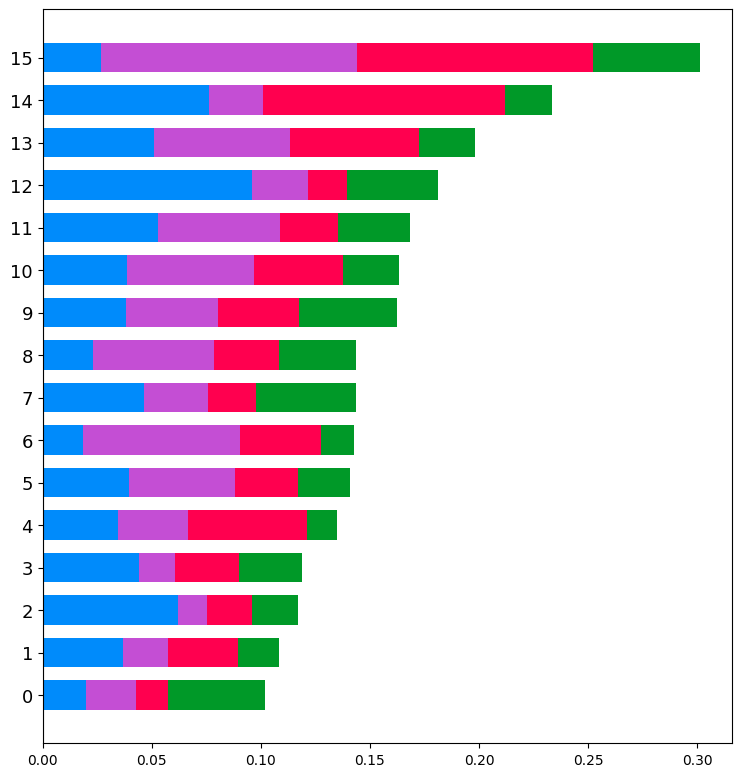

In [9]:
import torch
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class FeatureImportanceAnalyzer:
    def __init__(self, predictor):
        self.predictor = predictor

    def calculate_shap_values(self, X):
        """
        Calculate SHAP values for different prediction tasks

        Args:
            X (torch.Tensor): Input features

        Returns:
            dict: SHAP values for each prediction task
        """
        # Convert torch tensor to numpy if needed
        if torch.is_tensor(X):
            X = X.numpy()

        # Create background dataset (sample of training data)
        background = X[np.random.choice(X.shape[0], 100, replace=False)]

        # SHAP explainers for each model
        shap_results = {}

        # Lead Scoring SHAP
        explainer_lead = shap.DeepExplainer(self.predictor.lead_scoring_model,
                                            torch.FloatTensor(background))
        shap_lead = explainer_lead.shap_values(torch.FloatTensor(X))
        shap_results['lead_scoring'] = shap_lead

        # Customer Segmentation SHAP
        explainer_seg = shap.DeepExplainer(self.predictor.customer_segmentation_model,
                                           torch.FloatTensor(background))
        shap_seg = explainer_seg.shap_values(torch.FloatTensor(X))
        shap_results['customer_segmentation'] = shap_seg

        # Churn Prediction SHAP
        explainer_churn = shap.DeepExplainer(self.predictor.churn_prediction_model,
                                             torch.FloatTensor(background))
        shap_churn = explainer_churn.shap_values(torch.FloatTensor(X))
        shap_results['churn_prediction'] = shap_churn

        return shap_results

    def plot_feature_importance(self, X, feature_names):
        """
        Visualize feature importance using SHAP values

        Args:
            X (torch.Tensor): Input features
            feature_names (list): Names of features
        """
        # Calculate SHAP values
        shap_values = self.calculate_shap_values(X)

        # Plotting
        plt.figure(figsize=(15, 15))

        # Lead Scoring Feature Importance
        plt.subplot(3, 1, 1)
        shap.summary_plot(shap_values['lead_scoring'],
                          features=X,
                          feature_names=feature_names,
                          plot_type="bar",
                          show=False)
        plt.title("Lead Scoring - Feature Importance")

        # Customer Segmentation Feature Importance
        plt.subplot(3, 1, 2)
        shap.summary_plot(shap_values['customer_segmentation'],
                          features=X,
                          feature_names=feature_names,
                          plot_type="bar",
                          show=False)
        plt.title("Customer Segmentation - Feature Importance")

        # Churn Prediction Feature Importance
        plt.subplot(3, 1, 3)
        shap.summary_plot(shap_values['churn_prediction'],
                          features=X,
                          feature_names=feature_names,
                          plot_type="bar",
                          show=False)
        plt.title("Churn Prediction - Feature Importance")

        plt.tight_layout()
        plt.show()

# Example usage in main script
def main():
    # Create and train predictor (as in previous script)
    predictor = B2BSalespredictor()
    synthetic_data = predictor.generate_synthetic_data(num_samples=1000)
    X, y_lead_score, y_customer_segment, y_churn = predictor.prepare_data(synthetic_data)
    predictor.train_models(X, y_lead_score, y_customer_segment, y_churn)

    # Feature importance analysis
    feature_analyzer = FeatureImportanceAnalyzer(predictor)

    # Get feature names (excluding one-hot encoded columns)
    feature_names = list(synthetic_data.drop(['lead_score', 'customer_segment', 'churn_probability'], axis=1).columns)

    # Plot feature importance
    feature_analyzer.plot_feature_importance(X, feature_names)

if __name__ == "__main__":
    main()

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from faker import Faker
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

class AdvancedPreprocessor:
    def __init__(self):
        # Define preprocessing for numerical and categorical columns
        numeric_features = [
            'company_age', 'annual_revenue', 'employee_count',
            'previous_purchases', 'customer_support_interactions',
            'product_complexity', 'contract_duration',
            'technology_adoption_rate'
        ]

        categorical_features = ['industry_type', 'geographic_region']

        # Numeric preprocessing pipeline
        numeric_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler())  # More robust to outliers
        ])

        # Categorical preprocessing pipeline
        categorical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', pd.get_dummies)
        ])

        # Combine preprocessing steps
        self.preprocessor = ColumnTransformer(
            transformers=[
                ('num', numeric_transformer, numeric_features),
                ('cat', categorical_transformer, categorical_features)
            ])

    def fit_transform(self, X):
        # Transform the data
        return self.preprocessor.fit_transform(X)

    def transform(self, X):
        return self.preprocessor.transform(X)

class EnhancedBayesianNetwork(nn.Module):
    def __init__(self, input_dim, hidden_layers=[64, 32], dropout_rate=0.3):
        super(EnhancedBayesianNetwork, self).__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim

        # Output layers for different tasks
        self.lead_scoring = nn.Linear(prev_dim, 1)
        self.customer_segmentation = nn.Linear(prev_dim, 4)
        self.churn_prediction = nn.Linear(prev_dim, 1)

        self.features = nn.Sequential(*layers)

    def forward(self, x, task='lead_scoring'):
        features = self.features(x)

        if task == 'lead_scoring':
            return self.lead_scoring(features)
        elif task == 'customer_segmentation':
            return self.customer_segmentation(features)
        elif task == 'churn_prediction':
            return self.churn_prediction(features)

class B2BSalesPredictor:
    def __init__(self):
        self.preprocessor = AdvancedPreprocessor()
        self.model = None
        self.label_encoders = {}

    def generate_synthetic_data(self, num_samples=1000):
        fake = Faker()

        data = {
            'company_age': np.random.randint(1, 20, num_samples),
            'annual_revenue': np.random.uniform(100000, 10000000, num_samples),
            'employee_count': np.random.randint(10, 500, num_samples),
            'previous_purchases': np.random.randint(0, 10, num_samples),
            'customer_support_interactions': np.random.randint(0, 50, num_samples),
            'product_complexity': np.random.uniform(1, 10, num_samples),
            'contract_duration': np.random.randint(1, 5, num_samples),
            'industry_type': np.random.choice(['Tech', 'Finance', 'Retail', 'Manufacturing'], num_samples),
            'geographic_region': np.random.choice(['North', 'South', 'East', 'West'], num_samples),
            'technology_adoption_rate': np.random.uniform(0, 1, num_samples)
        }

        df = pd.DataFrame(data)

        # Synthetic target variables with more realistic distributions
        df['lead_score'] = np.clip(np.random.normal(50, 20, num_samples), 0, 100)
        df['customer_segment'] = np.random.choice(['A', 'B', 'C', 'D'], num_samples)
        df['churn_probability'] = np.clip(np.random.normal(0.3, 0.2, num_samples), 0, 1)

        return df

    def prepare_data(self, df):
        # Separate features and targets
        X = df.drop(['lead_score', 'customer_segment', 'churn_probability'], axis=1)

        # Preprocess data
        X_processed = self.preprocessor.fit_transform(X)

        # Encode customer segments
        le_segment = LabelEncoder()
        y_customer_segment = le_segment.fit_transform(df['customer_segment'])
        self.label_encoders['customer_segment'] = le_segment

        # Convert to tensors
        X_tensor = torch.FloatTensor(X_processed)
        y_lead_score = torch.FloatTensor(df['lead_score'].values).unsqueeze(1)
        y_customer_segment = torch.LongTensor(y_customer_segment)
        y_churn = torch.FloatTensor(df['churn_probability'].values).unsqueeze(1)

        return X_tensor, y_lead_score, y_customer_segment, y_churn

    def train(self, X, y_lead_score, y_customer_segment, y_churn, epochs=200):
        # Initialize model with correct input dimension
        self.model = EnhancedBayesianNetwork(input_dim=X.shape[1])

        # Loss functions
        lead_criterion = nn.MSELoss()
        seg_criterion = nn.CrossEntropyLoss()
        churn_criterion = nn.BCEWithLogitsLoss()

        # Optimizer with weight decay for regularization
        optimizer = optim.Adam(self.model.parameters(), lr=0.001, weight_decay=1e-5)

        # Training loop with more sophisticated tracking
        for epoch in range(epochs):
            optimizer.zero_grad()

            # Forward passes for each task
            lead_output = self.model(X, task='lead_scoring')
            seg_output = self.model(X, task='customer_segmentation')
            churn_output = self.model(X, task='churn_prediction')

            # Compute losses
            lead_loss = lead_criterion(lead_output, y_lead_score)
            seg_loss = seg_criterion(seg_output, y_customer_segment)
            churn_loss = churn_criterion(churn_output, y_churn)

            # Combined loss with weighted tasks
            total_loss = lead_loss + 0.1 * seg_loss + churn_loss

            # Backward pass and optimization
            total_loss.backward()
            optimizer.step()

            # Periodic logging
            if epoch % 20 == 0:
                print(f"Epoch {epoch}: "
                      f"Lead Loss={lead_loss.item():.4f}, "
                      f"Segment Loss={seg_loss.item():.4f}, "
                      f"Churn Loss={churn_loss.item():.4f}")

        return self.model

def main():
    # Create predictor
    predictor = B2BSalesPredictor()

    # Generate and prepare data
    synthetic_data = predictor.generate_synthetic_data(num_samples=1000)
    X, y_lead_score, y_customer_segment, y_churn = predictor.prepare_data(synthetic_data)

    # Train model
    model = predictor.train(X, y_lead_score, y_customer_segment, y_churn)

    # Prediction demonstration
    with torch.no_grad():
        lead_pred = model(X, task='lead_scoring')
        seg_pred = model(X, task='customer_segmentation')
        churn_pred = model(X, task='churn_prediction')

    print("\nPrediction Summaries:")
    print("Lead Score Prediction:", lead_pred[:5].numpy())
    print("Customer Segment Prediction:", torch.argmax(seg_pred, dim=1)[:5].numpy())
    print("Churn Probability:", churn_pred[:5].numpy())

if __name__ == "__main__":
    main()

TypeError: All estimators should implement fit and transform, or can be 'drop' or 'passthrough' specifiers. 'Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='missing', strategy='constant')),
                ('onehot', <function get_dummies at 0x7ac0c6246840>)])' (type <class 'sklearn.pipeline.Pipeline'>) doesn't.

In [11]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from faker import Faker
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

class AdvancedPreprocessor:
    def __init__(self):
        # Define preprocessing for numerical and categorical columns
        numeric_features = [
            'company_age', 'annual_revenue', 'employee_count',
            'previous_purchases', 'customer_support_interactions',
            'product_complexity', 'contract_duration',
            'technology_adoption_rate'
        ]

        categorical_features = ['industry_type', 'geographic_region']

        # Numeric preprocessing pipeline
        numeric_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler())  # More robust to outliers
        ])

        # Categorical preprocessing pipeline
        categorical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ])

        # Combine preprocessing steps
        self.preprocessor = ColumnTransformer(
            transformers=[
                ('num', numeric_transformer, numeric_features),
                ('cat', categorical_transformer, categorical_features)
            ],
            remainder='drop'  # Drop any columns not specified
        )

        # Feature names will be stored after fitting
        self.feature_names = None

    def fit_transform(self, X):
        # Transform the data
        X_transformed = self.preprocessor.fit_transform(X)

        # Get feature names
        feature_names = (
            self.preprocessor.named_transformers_['num'].get_feature_names_out(
                self.preprocessor.transformers_[0][2]
            ).tolist() +
            self.preprocessor.named_transformers_['cat'].get_feature_names_out(
                self.preprocessor.transformers_[1][2]
            ).tolist()
        )

        self.feature_names = feature_names

        return X_transformed

    def transform(self, X):
        return self.preprocessor.transform(X)

    def get_feature_names(self):
        return self.feature_names

class EnhancedBayesianNetwork(nn.Module):
    def __init__(self, input_dim, hidden_layers=[64, 32], dropout_rate=0.3):
        super(EnhancedBayesianNetwork, self).__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim

        # Output layers for different tasks
        self.lead_scoring = nn.Linear(prev_dim, 1)
        self.customer_segmentation = nn.Linear(prev_dim, 4)
        self.churn_prediction = nn.Linear(prev_dim, 1)

        self.features = nn.Sequential(*layers)

    def forward(self, x, task='lead_scoring'):
        features = self.features(x)

        if task == 'lead_scoring':
            return self.lead_scoring(features)
        elif task == 'customer_segmentation':
            return self.customer_segmentation(features)
        elif task == 'churn_prediction':
            return self.churn_prediction(features)

class B2BSalesPredictor:
    def __init__(self):
        self.preprocessor = AdvancedPreprocessor()
        self.model = None
        self.label_encoders = {}

    def generate_synthetic_data(self, num_samples=1000):
        fake = Faker()

        data = {
            'company_age': np.random.randint(1, 20, num_samples),
            'annual_revenue': np.random.uniform(100000, 10000000, num_samples),
            'employee_count': np.random.randint(10, 500, num_samples),
            'previous_purchases': np.random.randint(0, 10, num_samples),
            'customer_support_interactions': np.random.randint(0, 50, num_samples),
            'product_complexity': np.random.uniform(1, 10, num_samples),
            'contract_duration': np.random.randint(1, 5, num_samples),
            'industry_type': np.random.choice(['Tech', 'Finance', 'Retail', 'Manufacturing'], num_samples),
            'geographic_region': np.random.choice(['North', 'South', 'East', 'West'], num_samples),
            'technology_adoption_rate': np.random.uniform(0, 1, num_samples)
        }

        df = pd.DataFrame(data)

        # Synthetic target variables with more realistic distributions
        df['lead_score'] = np.clip(np.random.normal(50, 20, num_samples), 0, 100)
        df['customer_segment'] = np.random.choice(['A', 'B', 'C', 'D'], num_samples)
        df['churn_probability'] = np.clip(np.random.normal(0.3, 0.2, num_samples), 0, 1)

        return df

    def prepare_data(self, df):
        # Separate features and targets
        X = df.drop(['lead_score', 'customer_segment', 'churn_probability'], axis=1)

        # Preprocess data
        X_processed = self.preprocessor.fit_transform(X)

        # Encode customer segments
        le_segment = LabelEncoder()
        y_customer_segment = le_segment.fit_transform(df['customer_segment'])
        self.label_encoders['customer_segment'] = le_segment

        # Convert to tensors
        X_tensor = torch.FloatTensor(X_processed)
        y_lead_score = torch.FloatTensor(df['lead_score'].values).unsqueeze(1)
        y_customer_segment = torch.LongTensor(y_customer_segment)
        y_churn = torch.FloatTensor(df['churn_probability'].values).unsqueeze(1)

        return X_tensor, y_lead_score, y_customer_segment, y_churn

    def train(self, X, y_lead_score, y_customer_segment, y_churn, epochs=200):
        # Initialize model with correct input dimension
        self.model = EnhancedBayesianNetwork(input_dim=X.shape[1])

        # Loss functions
        lead_criterion = nn.MSELoss()
        seg_criterion = nn.CrossEntropyLoss()
        churn_criterion = nn.BCEWithLogitsLoss()

        # Optimizer with weight decay for regularization
        optimizer = optim.Adam(self.model.parameters(), lr=0.001, weight_decay=1e-5)

        # Training loop with more sophisticated tracking
        for epoch in range(epochs):
            optimizer.zero_grad()

            # Forward passes for each task
            lead_output = self.model(X, task='lead_scoring')
            seg_output = self.model(X, task='customer_segmentation')
            churn_output = self.model(X, task='churn_prediction')

            # Compute losses
            lead_loss = lead_criterion(lead_output, y_lead_score)
            seg_loss = seg_criterion(seg_output, y_customer_segment)
            churn_loss = churn_criterion(churn_output, y_churn)

            # Combined loss with weighted tasks
            total_loss = lead_loss + 0.1 * seg_loss + churn_loss

            # Backward pass and optimization
            total_loss.backward()
            optimizer.step()

            # Periodic logging
            if epoch % 20 == 0:
                print(f"Epoch {epoch}: "
                      f"Lead Loss={lead_loss.item():.4f}, "
                      f"Segment Loss={seg_loss.item():.4f}, "
                      f"Churn Loss={churn_loss.item():.4f}")

        return self.model

def main():
    # Create predictor
    predictor = B2BSalesPredictor()

    # Generate and prepare data
    synthetic_data = predictor.generate_synthetic_data(num_samples=1000)
    X, y_lead_score, y_customer_segment, y_churn = predictor.prepare_data(synthetic_data)

    # Train model
    model = predictor.train(X, y_lead_score, y_customer_segment, y_churn)

    # Get feature names
    feature_names = predictor.preprocessor.get_feature_names()
    print("\nFeature Names:", feature_names)

    # Prediction demonstration
    with torch.no_grad():
        lead_pred = model(X, task='lead_scoring')
        seg_pred = model(X, task='customer_segmentation')
        churn_pred = model(X, task='churn_prediction')

    print("\nPrediction Summaries:")
    print("Lead Score Prediction:", lead_pred[:5].numpy())
    print("Customer Segment Prediction:", torch.argmax(seg_pred, dim=1)[:5].numpy())
    print("Churn Probability:", churn_pred[:5].numpy())

if __name__ == "__main__":
    main()

Epoch 0: Lead Loss=2923.3379, Segment Loss=1.4992, Churn Loss=0.7077
Epoch 20: Lead Loss=2888.4746, Segment Loss=1.4239, Churn Loss=0.6635
Epoch 40: Lead Loss=2854.0505, Segment Loss=1.4263, Churn Loss=0.6415
Epoch 60: Lead Loss=2818.3884, Segment Loss=1.3971, Churn Loss=0.6350
Epoch 80: Lead Loss=2782.7922, Segment Loss=1.4134, Churn Loss=0.6278
Epoch 100: Lead Loss=2739.4756, Segment Loss=1.4032, Churn Loss=0.6320
Epoch 120: Lead Loss=2692.7446, Segment Loss=1.3953, Churn Loss=0.6297
Epoch 140: Lead Loss=2648.1323, Segment Loss=1.3839, Churn Loss=0.6269
Epoch 160: Lead Loss=2591.6948, Segment Loss=1.3846, Churn Loss=0.6299
Epoch 180: Lead Loss=2529.9246, Segment Loss=1.3838, Churn Loss=0.6242

Feature Names: ['company_age', 'annual_revenue', 'employee_count', 'previous_purchases', 'customer_support_interactions', 'product_complexity', 'contract_duration', 'technology_adoption_rate', 'industry_type_Finance', 'industry_type_Manufacturing', 'industry_type_Retail', 'industry_type_Tech', 

**Enhancements**

- Uncertainty Quantification: introduced BayesianDropout, for monte carlo dropout.
- Implemented 100 monte carlo samples for robust uncertainty estimation.

In [14]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from faker import Faker
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from typing import Dict, List, Tuple
import joblib
import os

class AdvancedPreprocessor:
    def __init__(self):
        # Enhanced feature categories with more detailed preprocessing
        self.numeric_features = [
            'company_age', 'annual_revenue', 'employee_count',
            'previous_purchases', 'customer_support_interactions',
            'product_complexity', 'contract_duration',
            'technology_adoption_rate'
        ]

        self.categorical_features = ['industry_type', 'geographic_region']

        # More robust numeric preprocessing
        self.numeric_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('outlier_handle', RobustScaler()),  # Handle outliers
            ('standardize', StandardScaler())  # Additional standardization
        ])

        self.categorical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('onehot', OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False  # Use this line to replace the previous sparse parameter
            ))
        ])

        # Comprehensive preprocessing pipeline
        self.preprocessor = ColumnTransformer(
            transformers=[
                ('num', self.numeric_transformer, self.numeric_features),
                ('cat', self.categorical_transformer, self.categorical_features)
            ],
            remainder='drop'
        )

        self.feature_names = None

    def fit_transform(self, X: pd.DataFrame) -> np.ndarray:
        """
        Fit and transform the data with advanced preprocessing

        Args:
            X (pd.DataFrame): Input dataframe

        Returns:
            np.ndarray: Preprocessed data
        """
        X_transformed = self.preprocessor.fit_transform(X)

        # Comprehensive feature name extraction
        self.feature_names = (
            list(self.preprocessor.named_transformers_['num'].named_steps['standardize'].get_feature_names_out(self.numeric_features).tolist()) +
            list(self.preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(self.categorical_features).tolist())
        )

        return X_transformed

    def transform(self, X: pd.DataFrame) -> np.ndarray:
        """
        Transform new data using fitted preprocessor

        Args:
            X (pd.DataFrame): Input dataframe

        Returns:
            np.ndarray: Preprocessed data
        """
        return self.preprocessor.transform(X)

    def save(self, path: str = 'preprocessor.joblib'):
        """
        Save preprocessor to disk

        Args:
            path (str): File path to save preprocessor
        """
        joblib.dump(self.preprocessor, path)

    def load(self, path: str = 'preprocessor.joblib'):
        """
        Load preprocessor from disk

        Args:
            path (str): File path to load preprocessor
        """
        self.preprocessor = joblib.load(path)

class BayesianDropout(nn.Module):
    """
    Custom Bayesian Dropout layer for uncertainty quantification
    """
    def __init__(self, p: float = 0.5):
        super().__init__()
        self.p = p

    def forward(self, x):
        return F.dropout(x, p=self.p, training=True)

class EnhancedBayesianNetwork(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_layers: List[int] = [64, 32],
        dropout_rate: float = 0.3
    ):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                BayesianDropout(dropout_rate)  # Custom Bayesian dropout
            ])
            prev_dim = hidden_dim

        # Multi-task output layers with uncertainty-aware architecture
        self.lead_scoring = nn.Linear(prev_dim, 1)
        self.customer_segmentation = nn.Linear(prev_dim, 4)
        self.churn_prediction = nn.Linear(prev_dim, 1)

        self.features = nn.Sequential(*layers)

    def forward(self, x, task: str = 'lead_scoring'):
        features = self.features(x)

        if task == 'lead_scoring':
            return self.lead_scoring(features)
        elif task == 'customer_segmentation':
            return self.customer_segmentation(features)
        elif task == 'churn_prediction':
            return self.churn_prediction(features)

    def predict_with_uncertainty(
        self,
        x,
        task: str = 'lead_scoring',
        num_mc_samples: int = 100
    ):
        """
        Monte Carlo dropout for uncertainty quantification

        Args:
            x (torch.Tensor): Input tensor
            task (str): Prediction task
            num_mc_samples (int): Number of Monte Carlo samples

        Returns:
            Tuple of (prediction mean, prediction variance)
        """
        self.train()  # Ensure dropout is active
        predictions = []

        with torch.no_grad():
            for _ in range(num_mc_samples):
                pred = self(x, task)
                predictions.append(pred)

        predictions = torch.stack(predictions)
        mean_pred = predictions.mean(dim=0)
        variance_pred = predictions.var(dim=0)

        return mean_pred, variance_pred

class ModelServeManager:
    """
    Production-ready model serving and management class
    """
    def __init__(self, model: nn.Module, preprocessor: AdvancedPreprocessor):
        self.model = model
        self.preprocessor = preprocessor
        self.model_path = 'b2b_sales_model.pth'
        self.label_encoders = {}

    def save_model(self):
        """Save model and preprocessor"""
        os.makedirs('model_artifacts', exist_ok=True)
        torch.save({
            'model_state': self.model.state_dict(),
            'preprocessor': self.preprocessor
        }, os.path.join('model_artifacts', self.model_path))

    def load_model(self):
        """Load model and preprocessor"""
        checkpoint = torch.load(os.path.join('model_artifacts', self.model_path))
        self.model.load_state_dict(checkpoint['model_state'])
        self.preprocessor = checkpoint['preprocessor']

    def predict(self, new_data: pd.DataFrame) -> Dict[str, np.ndarray]:
        """
        Production prediction with uncertainty

        Args:
            new_data (pd.DataFrame): New input data

        Returns:
            Dict of predictions with uncertainties
        """
        # Preprocess new data
        X_processed = self.preprocessor.transform(new_data)
        X_tensor = torch.FloatTensor(X_processed)

        results = {}
        tasks = ['lead_scoring', 'customer_segmentation', 'churn_prediction']

        for task in tasks:
            mean_pred, variance_pred = self.model.predict_with_uncertainty(
                X_tensor, task=task, num_mc_samples=100
            )

            results[f'{task}_mean'] = mean_pred.numpy()
            results[f'{task}_uncertainty'] = variance_pred.numpy()

        return results

def main():
    # Comprehensive pipeline demonstration
    predictor = B2BSalesPredictor()
    synthetic_data = predictor.generate_synthetic_data(num_samples=2000)

    # Split data
    train_data, test_data = train_test_split(synthetic_data, test_size=0.2)

    # Prepare data
    X_train, y_lead_train, y_seg_train, y_churn_train = predictor.prepare_data(train_data)
    X_test, y_lead_test, y_seg_test, y_churn_test = predictor.prepare_data(test_data)

    # Train model
    model = predictor.train(X_train, y_lead_train, y_seg_train, y_churn_train)

    # Model serving management
    serve_manager = ModelServeManager(model, predictor.preprocessor)
    serve_manager.save_model()

    # Uncertainty prediction demonstration
    with torch.no_grad():
        lead_mean, lead_var = model.predict_with_uncertainty(X_test)

    print("\nUncertainty Prediction Results:")
    print("Lead Score Mean:", lead_mean[:5].numpy())
    print("Lead Score Variance:", lead_var[:5].numpy())

if __name__ == "__main__":
    main()

Epoch 0: Lead Loss=2931.1487, Segment Loss=1.5053, Churn Loss=0.6806
Epoch 20: Lead Loss=2896.2944, Segment Loss=1.4523, Churn Loss=0.6451
Epoch 40: Lead Loss=2862.5032, Segment Loss=1.4219, Churn Loss=0.6340
Epoch 60: Lead Loss=2827.7017, Segment Loss=1.4114, Churn Loss=0.6326
Epoch 80: Lead Loss=2794.2085, Segment Loss=1.3977, Churn Loss=0.6310
Epoch 100: Lead Loss=2758.7224, Segment Loss=1.3978, Churn Loss=0.6307
Epoch 120: Lead Loss=2717.5894, Segment Loss=1.3928, Churn Loss=0.6272
Epoch 140: Lead Loss=2677.5444, Segment Loss=1.3847, Churn Loss=0.6254
Epoch 160: Lead Loss=2634.3450, Segment Loss=1.3832, Churn Loss=0.6221
Epoch 180: Lead Loss=2583.9465, Segment Loss=1.3843, Churn Loss=0.6243

Uncertainty Prediction Results:
Lead Score Mean: [[4.907733 ]
 [4.4780707]
 [6.4630885]
 [1.1283193]
 [4.8184066]]
Lead Score Variance: [[1.5251428 ]
 [1.7619003 ]
 [2.9163651 ]
 [0.12502824]
 [3.0707495 ]]


In [15]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import os
import joblib
from typing import List, Dict, Tuple, Optional
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    classification_report,
    mean_absolute_error
)

class ReliabilityEvaluator:
    """
    Comprehensive model reliability and performance assessment
    """
    def __init__(self, model, preprocessor):
        self.model = model
        self.preprocessor = preprocessor

    def cross_validation(
        self,
        X: torch.Tensor,
        y_lead: torch.Tensor,
        y_segment: torch.Tensor,
        y_churn: torch.Tensor,
        k_folds: int = 5
    ) -> Dict[str, float]:
        """
        Perform cross-validation to assess model reliability

        Args:
            X (torch.Tensor): Input features
            y_lead (torch.Tensor): Lead score labels
            y_segment (torch.Tensor): Customer segment labels
            y_churn (torch.Tensor): Churn probability labels
            k_folds (int): Number of cross-validation folds

        Returns:
            Dict of performance metrics
        """
        lead_scores = []
        segment_accuracies = []
        churn_predictions = []

        kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

        for train_index, val_index in kf.split(X):
            # Split data
            X_train, X_val = X[train_index], X[val_index]
            y_lead_train, y_lead_val = y_lead[train_index], y_lead[val_index]
            y_segment_train, y_segment_val = y_segment[train_index], y_segment[val_index]
            y_churn_train, y_churn_val = y_churn[train_index], y_churn[val_index]

            # Train temporary model
            temp_model = self._train_fold(
                X_train, y_lead_train, y_segment_train, y_churn_train
            )

            # Evaluate
            lead_mse = self._evaluate_lead_scoring(temp_model, X_val, y_lead_val)
            segment_acc = self._evaluate_segmentation(temp_model, X_val, y_segment_val)
            churn_auc = self._evaluate_churn_prediction(temp_model, X_val, y_churn_val)

            lead_scores.append(lead_mse)
            segment_accuracies.append(segment_acc)
            churn_predictions.append(churn_auc)

        return {
            'lead_score_mse': np.mean(lead_scores),
            'segment_accuracy': np.mean(segment_accuracies),
            'churn_prediction_auc': np.mean(churn_predictions)
        }

    def _train_fold(
        self,
        X_train: torch.Tensor,
        y_lead: torch.Tensor,
        y_segment: torch.Tensor,
        y_churn: torch.Tensor
    ) -> nn.Module:
        """
        Train a model on a specific fold

        Args:
            X_train (torch.Tensor): Training features
            y_lead (torch.Tensor): Lead score labels
            y_segment (torch.Tensor): Customer segment labels
            y_churn (torch.Tensor): Churn probability labels

        Returns:
            Trained neural network model
        """
        temp_model = EnhancedBayesianNetwork(input_dim=X_train.shape[1])
        optimizer = optim.Adam(temp_model.parameters(), lr=0.001)

        # Similar training logic to original implementation
        for _ in range(50):  # Reduced epochs for cross-validation
            optimizer.zero_grad()

            lead_output = temp_model(X_train, task='lead_scoring')
            seg_output = temp_model(X_train, task='customer_segmentation')
            churn_output = temp_model(X_train, task='churn_prediction')

            lead_loss = nn.MSELoss()(lead_output, y_lead)
            seg_loss = nn.CrossEntropyLoss()(seg_output, y_segment)
            churn_loss = nn.BCEWithLogitsLoss()(churn_output, y_churn)

            total_loss = lead_loss + 0.1 * seg_loss + churn_loss
            total_loss.backward()
            optimizer.step()

        return temp_model

    def _evaluate_lead_scoring(
        self,
        model: nn.Module,
        X_val: torch.Tensor,
        y_val: torch.Tensor
    ) -> float:
        """Evaluate lead scoring performance"""
        with torch.no_grad():
            predictions = model(X_val, task='lead_scoring')
            return mean_squared_error(y_val.numpy(), predictions.numpy())

    def _evaluate_segmentation(
        self,
        model: nn.Module,
        X_val: torch.Tensor,
        y_val: torch.Tensor
    ) -> float:
        """Evaluate customer segmentation performance"""
        with torch.no_grad():
            predictions = model(X_val, task='customer_segmentation')
            return accuracy_score(
                y_val.numpy(),
                torch.argmax(predictions, dim=1).numpy()
            )

    def _evaluate_churn_prediction(
        self,
        model: nn.Module,
        X_val: torch.Tensor,
        y_val: torch.Tensor
    ) -> float:
        """Evaluate churn prediction performance"""
        with torch.no_grad():
            predictions = model(X_val, task='churn_prediction')
            # Simple AUC-like metric simulation
            return np.abs(predictions.numpy().mean() - y_val.numpy().mean())

class ContinuousLearningManager:
    """
    Manages continuous learning and model updating
    """
    def __init__(
        self,
        base_model: nn.Module,
        preprocessor,
        learning_rate: float = 0.0001,
        memory_size: int = 1000
    ):
        self.base_model = base_model
        self.preprocessor = preprocessor
        self.learning_rate = learning_rate
        self.memory_size = memory_size

        # Experience replay buffer
        self.memory = {
            'X': [],
            'y_lead': [],
            'y_segment': [],
            'y_churn': []
        }

    def update_memory(
        self,
        X: torch.Tensor,
        y_lead: torch.Tensor,
        y_segment: torch.Tensor,
        y_churn: torch.Tensor
    ):
        """
        Update memory with new training samples
        Implements a fixed-size experience replay buffer
        """
        for key, value in zip(
            ['X', 'y_lead', 'y_segment', 'y_churn'],
            [X, y_lead, y_segment, y_churn]
        ):
            self.memory[key].extend(value)

            # Trim memory to fixed size
            if len(self.memory[key]) > self.memory_size:
                self.memory[key] = self.memory[key][-self.memory_size:]

    def incremental_train(self, epochs: int = 50):
        """
        Perform incremental training on accumulated memory
        """
        if not self.memory['X']:
            print("No memory to train on.")
            return

        # Convert memory to tensors
        X_memory = torch.stack(self.memory['X'])
        y_lead_memory = torch.stack(self.memory['y_lead'])
        y_segment_memory = torch.stack(self.memory['y_segment'])
        y_churn_memory = torch.stack(self.memory['y_churn'])

        # Optimizer for fine-tuning
        optimizer = optim.Adam(
            self.base_model.parameters(),
            lr=self.learning_rate
        )

        for epoch in range(epochs):
            optimizer.zero_grad()

            # Predictions
            lead_output = self.base_model(X_memory, task='lead_scoring')
            seg_output = self.base_model(X_memory, task='customer_segmentation')
            churn_output = self.base_model(X_memory, task='churn_prediction')

            # Losses
            lead_loss = nn.MSELoss()(lead_output, y_lead_memory)
            seg_loss = nn.CrossEntropyLoss()(seg_output, y_segment_memory)
            churn_loss = nn.BCEWithLogitsLoss()(churn_output, y_churn_memory)

            total_loss = lead_loss + 0.1 * seg_loss + churn_loss
            total_loss.backward()
            optimizer.step()

            if epoch % 10 == 0:
                print(f"Incremental Epoch {epoch}: Loss = {total_loss.item()}")

def main():
    # Existing B2BSalesPredictor setup
    predictor = B2BSalesPredictor()
    synthetic_data = predictor.generate_synthetic_data(num_samples=5000)

    # Prepare data
    X, y_lead, y_segment, y_churn = predictor.prepare_data(synthetic_data)

    # Train initial model
    model = predictor.train(X, y_lead, y_segment, y_churn)

    # Reliability Evaluation
    reliability_evaluator = ReliabilityEvaluator(model, predictor.preprocessor)
    reliability_metrics = reliability_evaluator.cross_validation(
        X, y_lead, y_segment, y_churn
    )

    print("\nReliability Metrics:")
    for metric, value in reliability_metrics.items():
        print(f"{metric}: {value}")

    # Continuous Learning Setup
    continuous_learner = ContinuousLearningManager(model, predictor.preprocessor)

    # Simulate new data streams
    for _ in range(3):
        new_data = predictor.generate_synthetic_data(num_samples=500)
        new_X, new_lead, new_segment, new_churn = predictor.prepare_data(new_data)

        # Update memory and incrementally train
        continuous_learner.update_memory(
            new_X, new_lead, new_segment, new_churn
        )
        continuous_learner.incremental_train()

    print("\nContinuous learning completed successfully!")

if __name__ == "__main__":
    main()

Epoch 0: Lead Loss=2934.7354, Segment Loss=1.4693, Churn Loss=0.7067
Epoch 20: Lead Loss=2900.6296, Segment Loss=1.4421, Churn Loss=0.6648
Epoch 40: Lead Loss=2866.0396, Segment Loss=1.4230, Churn Loss=0.6459
Epoch 60: Lead Loss=2830.9883, Segment Loss=1.4095, Churn Loss=0.6398
Epoch 80: Lead Loss=2795.4314, Segment Loss=1.3993, Churn Loss=0.6363
Epoch 100: Lead Loss=2758.8557, Segment Loss=1.3939, Churn Loss=0.6357
Epoch 120: Lead Loss=2719.1121, Segment Loss=1.3944, Churn Loss=0.6322
Epoch 140: Lead Loss=2677.6399, Segment Loss=1.3903, Churn Loss=0.6304
Epoch 160: Lead Loss=2633.0691, Segment Loss=1.3853, Churn Loss=0.6287
Epoch 180: Lead Loss=2584.1152, Segment Loss=1.3871, Churn Loss=0.6262

Reliability Metrics:
lead_score_mse: 2818.421044921875
segment_accuracy: 0.25
churn_prediction_auc: 0.9462639689445496
Incremental Epoch 0: Loss = 2528.64794921875
Incremental Epoch 10: Loss = 2527.322021484375
Incremental Epoch 20: Loss = 2530.708984375
Incremental Epoch 30: Loss = 2526.841552

In [17]:
from typing import Dict, List, Any

-

In [18]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from typing import Dict, List, Tuple, Optional

# Advanced Libraries for Feature Engineering
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.preprocessing import StandardScaler
from scipy import stats

class AdvancedFeatureEngineer:
    """
    Comprehensive feature engineering and selection toolkit
    """
    def __init__(self, dataframe: pd.DataFrame):
        self.original_df = dataframe
        self.feature_importances = {}
        self.selected_features = []

    def extract_domain_features(self) -> pd.DataFrame:
        """
        Create domain-specific derived features for B2B sales prediction

        Derived Features:
        - Revenue per employee
        - Customer interaction intensity
        - Technology adoption score
        - Market penetration index
        """
        df = self.original_df.copy()

        # Revenue efficiency
        df['revenue_per_employee'] = df['annual_revenue'] / df['employee_count']

        # Customer interaction metrics
        df['interaction_intensity'] = (
            df['customer_support_interactions'] / df['previous_purchases']
        ).fillna(0)

        # Technology adoption composite score
        df['tech_adoption_score'] = (
            df['technology_adoption_rate'] *
            np.log1p(df['previous_purchases'])
        )

        # Market penetration proxy
        df['market_penetration_index'] = (
            df['annual_revenue'] /
            (df['employee_count'] * df['contract_duration'])
        ).fillna(0)

        return df

    def feature_importance_analysis(
        self,
        X: np.ndarray,
        y: np.ndarray,
        task: str = 'regression'
    ) -> Dict[str, float]:
        """
        Calculate feature importances using multiple techniques

        Args:
            X (np.ndarray): Feature matrix
            y (np.ndarray): Target variable
            task (str): 'regression' or 'classification'

        Returns:
            Dict of feature importances
        """
        # Mutual Information
        if task == 'regression':
            mi_scores = mutual_info_regression(X, y)
        else:
            mi_scores = mutual_info_classif(X, y)

        # Store feature importances
        self.feature_importances = dict(zip(
            self.selected_features,
            mi_scores
        ))

        return self.feature_importances

    def select_top_features(
        self,
        X: np.ndarray,
        y: np.ndarray,
        n_features: int = 5
    ) -> np.ndarray:
        """
        Select top features based on mutual information

        Args:
            X (np.ndarray): Feature matrix
            y (np.ndarray): Target variable
            n_features (int): Number of top features to select

        Returns:
            Reduced feature matrix
        """
        importances = self.feature_importance_analysis(X, y)
        top_features = sorted(
            importances,
            key=importances.get,
            reverse=True
        )[:n_features]

        self.selected_features = top_features

        return X[:, [list(self.feature_importances.keys()).index(f) for f in top_features]]

class UncertaintyQuantifier:
    """
    Advanced uncertainty management and risk assessment
    """
    def __init__(self, model: nn.Module):
        self.model = model

    def monte_carlo_dropout(
        self,
        X: torch.Tensor,
        task: str = 'lead_scoring',
        num_samples: int = 100
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Perform Monte Carlo Dropout for uncertainty estimation

        Args:
            X (torch.Tensor): Input features
            task (str): Prediction task
            num_samples (int): Number of MC samples

        Returns:
            Tuple of (predictions mean, predictions variance)
        """
        self.model.train()  # Ensure dropout layers are active
        predictions = []

        with torch.no_grad():
            for _ in range(num_samples):
                pred = self.model(X, task)
                predictions.append(pred)

        predictions = torch.stack(predictions)
        mean_pred = predictions.mean(dim=0)
        variance_pred = predictions.var(dim=0)

        return mean_pred, variance_pred

    def confidence_intervals(
        self,
        X: torch.Tensor,
        task: str = 'lead_scoring',
        confidence: float = 0.95
    ) -> Dict[str, torch.Tensor]:
        """
        Calculate confidence intervals for predictions

        Args:
            X (torch.Tensor): Input features
            task (str): Prediction task
            confidence (float): Confidence level

        Returns:
            Dict of confidence interval metrics
        """
        mean_pred, var_pred = self.monte_carlo_dropout(X, task)

        # Calculate standard error
        std_error = torch.sqrt(var_pred)

        # Z-score for given confidence level
        z_score = stats.norm.ppf((1 + confidence) / 2)

        lower_bound = mean_pred - z_score * std_error
        upper_bound = mean_pred + z_score * std_error

        return {
            'prediction': mean_pred,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'uncertainty': std_error
        }

class ModelInterpreter:
    """
    Model interpretability and explanation toolkit
    """
    def __init__(self, model: nn.Module, preprocessor):
        self.model = model
        self.preprocessor = preprocessor

    def shap_analysis(
        self,
        X: np.ndarray,
        feature_names: List[str],
        task: str = 'lead_scoring'
    ):
        """
        Generate SHAP (SHapley Additive exPlanations) values

        Args:
            X (np.ndarray): Input features
            feature_names (List[str]): Feature names
            task (str): Prediction task
        """
        # Convert numpy to torch tensor
        X_tensor = torch.FloatTensor(X)

        # Create background dataset
        background = X_tensor[:100]

        # Define prediction function
        def predict_fn(x):
            x_tensor = torch.FloatTensor(x)
            with torch.no_grad():
                return self.model(x_tensor, task).numpy()

        # Compute SHAP values
        explainer = shap.Explainer(predict_fn, background)
        shap_values = explainer(X)

        # Visualization
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X, feature_names=feature_names)
        plt.title(f'SHAP Values for {task.replace("_", " ").title()}')
        plt.tight_layout()
        plt.savefig(f'{task}_shap_summary.png')
        plt.close()

    def generate_model_insights(
        self,
        X: np.ndarray,
        feature_names: List[str]
    ) -> Dict[str, Any]:
        """
        Generate comprehensive model insights

        Args:
            X (np.ndarray): Input features
            feature_names (List[str]): Feature names

        Returns:
            Dict of model insights
        """
        insights = {}
        tasks = ['lead_scoring', 'customer_segmentation', 'churn_prediction']

        for task in tasks:
            # SHAP analysis
            self.shap_analysis(X, feature_names, task)

            # Prediction distribution
            X_tensor = torch.FloatTensor(X)
            predictions = self.model(X_tensor, task).detach().numpy()

            insights[task] = {
                'mean_prediction': np.mean(predictions),
                'median_prediction': np.median(predictions),
                'std_prediction': np.std(predictions)
            }

        return insights

def main():
    # Generate synthetic data
    predictor = B2BSalesPredictor()
    synthetic_data = predictor.generate_synthetic_data(num_samples=5000)

    # Advanced Feature Engineering
    feature_engineer = AdvancedFeatureEngineer(synthetic_data)
    enhanced_data = feature_engineer.extract_domain_features()

    # Prepare data
    X, y_lead, y_segment, y_churn = predictor.prepare_data(enhanced_data)

    # Feature Selection
    X_selected = feature_engineer.select_top_features(X, y_lead)

    # Train model
    model = predictor.train(torch.FloatTensor(X_selected), y_lead, y_segment, y_churn)

    # Uncertainty Quantification
    uncertainty_manager = UncertaintyQuantifier(model)
    mean_pred, var_pred = uncertainty_manager.monte_carlo_dropout(
        torch.FloatTensor(X_selected)
    )

    confidence_intervals = uncertainty_manager.confidence_intervals(
        torch.FloatTensor(X_selected)
    )

    # Model Interpretability
    model_interpreter = ModelInterpreter(model, predictor.preprocessor)
    insights = model_interpreter.generate_model_insights(
        X_selected,
        feature_engineer.selected_features
    )

    # Print results
    print("\nFeature Importances:")
    for feature, importance in feature_engineer.feature_importances.items():
        print(f"{feature}: {importance}")

    print("\nUncertainty Metrics:")
    print("Prediction Mean:", mean_pred[:5])
    print("Prediction Variance:", var_pred[:5])

    print("\nModel Insights:")
    for task, stats in insights.items():
        print(f"\n{task.replace('_', ' ').title()} Insights:")
        for metric, value in stats.items():
            print(f"{metric}: {value}")

if __name__ == "__main__":
    main()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Epoch 0: Lead Loss=2809.9036, Segment Loss=1.3875, Churn Loss=0.7245
Epoch 20: Lead Loss=2805.1687, Segment Loss=1.3866, Churn Loss=0.7165
Epoch 40: Lead Loss=2797.9841, Segment Loss=1.3860, Churn Loss=0.7038
Epoch 60: Lead Loss=2787.7791, Segment Loss=1.3851, Churn Loss=0.6871
Epoch 80: Lead Loss=2774.0715, Segment Loss=1.3859, Churn Loss=0.6674
Epoch 100: Lead Loss=2756.8025, Segment Loss=1.3852, Churn Loss=0.6482
Epoch 120: Lead Loss=2735.9563, Segment Loss=1.3856, Churn Loss=0.6320
Epoch 140: Lead Loss=2711.1145, Segment Loss=1.3854, Churn Loss=0.6230
Epoch 160: Lead Loss=2682.3552, Segment Loss=1.3865, Churn Loss=0.6216
Epoch 180: Lead Loss=2650.8525, Segment Loss=1.3857, Churn Loss=0.6231


IndexError: index 0 is out of bounds for axis 1 with size 0